In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import datetime

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')

from python.postprocess import *
from python.animation import *
from autoencoder.src.data_loader import *
from autoencoder.min2.run_models import *

from tensorflow.keras.datasets import fashion_mnist

In [ ]:
# TODO: use an artificial dataset 
# TODO: fourier transform/PCA; reconstruct weights of the PCA 
# plot the heatmap of each time window (batch by time); roaster
# downsample in time in the VAE; or just flatten the time dimension into feature dimension

# Generate artificial jellyfish dataset

canvas size = (200, 200)

center position = (100, 100)

tentacle bulb count = 17

max radius = 60

period for one swim pulse = 20 - 50 frames 

P(swim) = 0.9, P(still) = 0.1 

period of still = 5 - 20 frames

contraction ratio = 0.2 - 0.8

frame count = 5000

Assume no rotation, i.e., each point is always on the same radius. At each time stamp, radius of all points are the same. 

In [2]:
def generate_jellyfish_dataset(
    tb_cnt=17, 
    frame_cnt=5000, 
    max_r=60, 
    p_swim=0.8, 
    t_swim=(20, 50), 
    t_still=(5, 20), 
    contract_ratio=(0.2, 0.8), 
    center_pos=(100, 100)):
    
    radius_data = np.zeros(frame_cnt)
    radius_data[0] = max_r # start from max radius 
    frame_idx = 1
    while frame_idx < frame_cnt:
        # Generate swim or still state
        if np.random.rand() < p_swim: # Swim state
            swim_duration = np.random.randint(*t_swim)
            swim_duration = swim_duration - 1 if swim_duration % 2 == 1 else swim_duration # make sure the duration is even 
            swim_start = frame_idx
            swim_end = min(frame_idx + swim_duration, frame_cnt)
            swim_mid = min(swim_start + swim_duration // 2, frame_cnt)
            min_r = np.random.uniform(*contract_ratio) * max_r
            r_series = np.linspace(max_r, min_r, swim_duration // 2)
            radius_data[swim_start : swim_mid] = r_series[:swim_mid - swim_start]
            if swim_mid >= frame_cnt:
                break
            radius_data[swim_mid : swim_end] = r_series[::-1][:swim_end - swim_mid]
            frame_idx = swim_end
        else: # still state
            still_duration = np.random.randint(*t_still)
            still_end = min(frame_idx + still_duration, frame_cnt)
            radius_data[frame_idx : still_end] = radius_data[frame_idx - 1]
            frame_idx = still_end
    
    radius_data = np.broadcast_to(radius_data[:, None], (frame_cnt, tb_cnt))
    theta_data = np.linspace(-np.pi, np.pi, tb_cnt, endpoint=False)
    
    dataset = np.zeros((frame_cnt, tb_cnt, 2))
    dataset[:, :, 0] = radius_data * np.cos(theta_data)
    dataset[:, :, 1] = radius_data * np.sin(theta_data)
    dataset += center_pos
    
    return dataset            

In [3]:
toy_jelly = generate_jellyfish_dataset()
toy_jelly_path = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/notebook/toy_jelly_v1.npy'
np.save(toy_jelly_path, toy_jelly)
print(toy_jelly.shape)

(5000, 17, 2)


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/toy_jelly_v1.mp4
Animation saved to /home/mingxiao/Desktop/animation/toy_jelly_v1.mp4


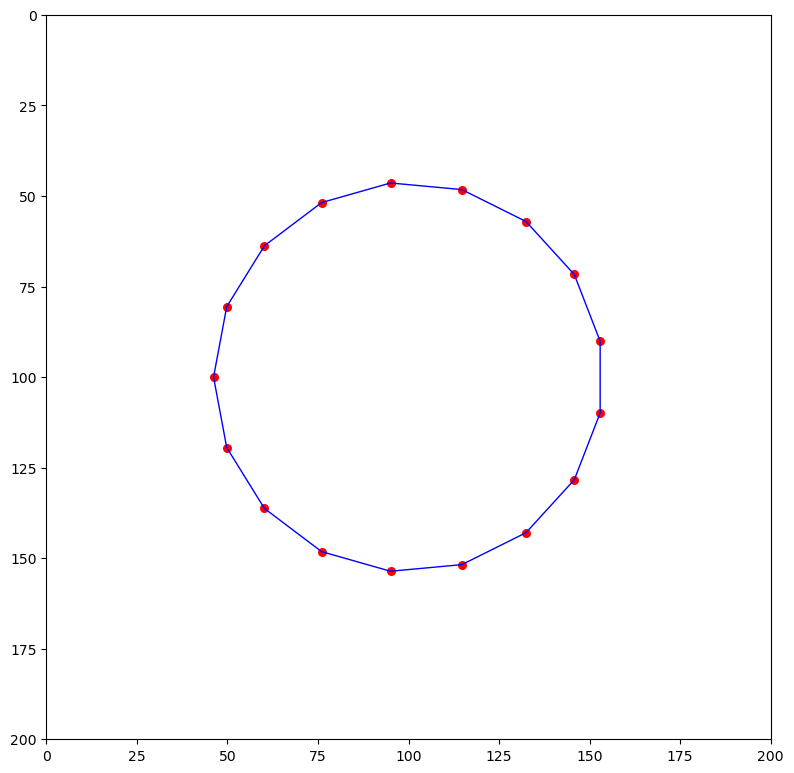

In [4]:
toy_jelly_animation_path = '/home/mingxiao/Desktop/animation/toy_jelly_v1.mp4'
get_animation_from_tracked_points(toy_jelly, 200, 200, 50, bg_video=None, bg_video_start_idx=0, output_path=toy_jelly_animation_path);

# Generate dataset for AE training

# Train AE